<a href="https://colab.research.google.com/github/HozaifAwan/digital-pathology-benchmarking/blob/main/HC_Digital_Pathology_Experiment_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torchvision

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128
CUDA available: True
GPU: Tesla T4


README.md:   0%|          | 0.00/1.92k [00:00<?, ?B/s]

dict_keys(['image', 'label'])
Image size: (96, 96)
Label: 0


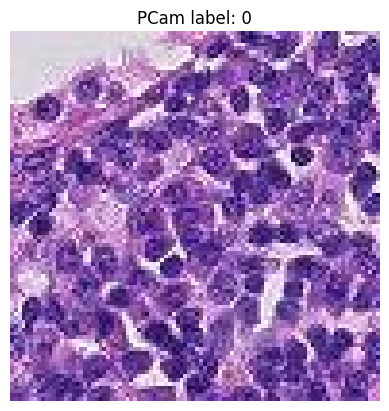

In [ ]:
!pip -q install datasets

from datasets import load_dataset
import matplotlib.pyplot as plt

# Stream PCam from Hugging Face instead of downloading everything
pcam = load_dataset(
    "zacharielegault/PatchCamelyon",
    split="train",
    streaming=True
)

# Grab only the first sample
sample = next(iter(pcam))

print(sample.keys())

image = sample["image"]
label = sample["label"]

print("Image size:", image.size)
print("Label:", label)

plt.imshow(image)
plt.axis("off")
plt.title(f"PCam label: {label}")
plt.show()

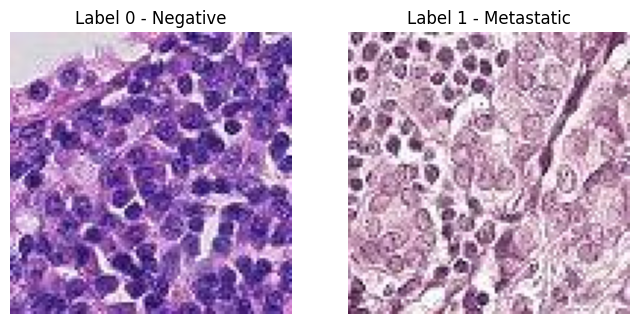

In [ ]:
negative_sample = None
positive_sample = None

for sample in pcam:
    if sample["label"] == 0 and negative_sample is None:
        negative_sample = sample

    if sample["label"] == 1 and positive_sample is None:
        positive_sample = sample

    if negative_sample is not None and positive_sample is not None:
        break

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(negative_sample["image"])
axes[0].set_title("Label 0 - Negative")
axes[0].axis("off")

axes[1].imshow(positive_sample["image"])
axes[1].set_title("Label 1 - Metastatic")
axes[1].axis("off")

plt.show()

In [ ]:
from torchvision import transforms

# Convert the pathology image into a PyTorch tensor
to_tensor = transforms.ToTensor()

image_tensor = to_tensor(positive_sample["image"])

print("Tensor shape:", image_tensor.shape)
print("Data type:", image_tensor.dtype)
print("Minimum pixel value:", image_tensor.min().item())
print("Maximum pixel value:", image_tensor.max().item())

print("\nFirst few values:")
print(image_tensor[:, :3, :3])

Tensor shape: torch.Size([3, 96, 96])
Data type: torch.float32
Minimum pixel value: 0.0
Maximum pixel value: 1.0

First few values:
tensor([[[0.8824, 0.5725, 0.3686],
         [1.0000, 0.2353, 0.6392],
         [0.9922, 0.3333, 0.4078]],

        [[0.7882, 0.4784, 0.2667],
         [0.9451, 0.1412, 0.5373],
         [0.8980, 0.2392, 0.3059]],

        [[0.8824, 0.5725, 0.3647],
         [1.0000, 0.2353, 0.6353],
         [0.9922, 0.3333, 0.4039]]])


In [ ]:
import torch
device = torch.device("cuda")

print("Before transfer:")
print("Tensor location:", image_tensor.device)

gpu_tensor = image_tensor.to(device)

print("\nAfter transfer:")
print("Tensor location:", gpu_tensor.device)
print("Tensor shape:", gpu_tensor.shape)

Before transfer:
Tensor location: cpu

After transfer:
Tensor location: cuda:0
Tensor shape: torch.Size([3, 96, 96])


In [ ]:
images = []
labels = []

for sample in pcam:
    image = to_tensor(sample["image"])

    images.append(image)
    labels.append(sample["label"])

    if len(images) == 32:
        break

batch = torch.stack(images)
labels = torch.tensor(labels)

print("Batch shape:", batch.shape)
print("Labels shape:", labels.shape)
print("First 10 labels:", labels[:10])
print("Batch location:", batch.device)

gpu_batch = batch.to("cuda")

print("GPU batch location:", gpu_batch.device)
print("GPU batch shape:", gpu_batch.shape)

Batch shape: torch.Size([32, 3, 96, 96])
Labels shape: torch.Size([32])
First 10 labels: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
Batch location: cpu
GPU batch location: cuda:0
GPU batch shape: torch.Size([32, 3, 96, 96])


In [ ]:
from torchvision import models
import torch.nn as nn

# Load ResNet18 with pretrained ImageNet weights
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Replace the original output layer with a 2-class output
model.fc = nn.Linear(model.fc.in_features, 2)

# Move the model onto the Tesla T4
model = model.to("cuda")

print("Final layer:")
print(model.fc)

print("\nModel location:")
print(next(model.parameters()).device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 159MB/s]


Final layer:
Linear(in_features=512, out_features=2, bias=True)

Model location:
cuda:0


In [ ]:
import torch.optim as optim

# Function that measures how wrong the model's predictions are
criterion = nn.CrossEntropyLoss()

# Optimizer updates the model's weights so it gets better
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Loss function:", criterion)
print("Optimizer:", optimizer.__class__.__name__)
print("Learning rate:", optimizer.param_groups[0]["lr"])

Loss function: CrossEntropyLoss()
Optimizer: Adam
Learning rate: 0.001


In [ ]:
train_images = []
train_labels = []

negative_count = 0
positive_count = 0

for sample in pcam:

    label = sample["label"]

    if label == 0 and negative_count >= 16:
        continue

    if label == 1 and positive_count >= 16:
        continue

    image = to_tensor(sample["image"])

    train_images.append(image)
    train_labels.append(label)

    if label == 0:
        negative_count += 1
    else:
        positive_count += 1

    if negative_count == 16 and positive_count == 16:
        break

train_batch = torch.stack(train_images).to("cuda")
train_labels = torch.tensor(train_labels).to("cuda")

print("Training batch:", train_batch.shape)
print("Negative samples:", negative_count)
print("Metastatic samples:", positive_count)
print("Images location:", train_batch.device)
print("Labels location:", train_labels.device)

Training batch: torch.Size([32, 3, 96, 96])
Negative samples: 16
Metastatic samples: 16
Images location: cuda:0
Labels location: cuda:0


In [ ]:
from torchvision import transforms

# Prepare PCam images for the ImageNet-pretrained ResNet18
pcam_transform = transforms.Compose([
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("ResNet18 preprocessing ready.")

ResNet18 preprocessing ready.


09/18/26


In [ ]:
from google.colab import drive
import os

drive.mount("/content/drive")

PCAM_DRIVE = "/content/drive/MyDrive/HC_Project/PCam"
PCAM_LOCAL = "/content/pcam_data"

os.makedirs(PCAM_DRIVE, exist_ok=True)
os.makedirs(PCAM_LOCAL, exist_ok=True)

print("Permanent PCam folder:", PCAM_DRIVE)
print("Temporary Colab folder:", PCAM_LOCAL)

Mounted at /content/drive
Permanent PCam folder: /content/drive/MyDrive/HC_Project/PCam
Temporary Colab folder: /content/pcam_data


In [ ]:
import os
import urllib.request

BASE_URL = "https://zenodo.org/records/2546921/files"

PCAM_FILES = [
    "camelyonpatch_level_2_split_train_x.h5.gz",
    "camelyonpatch_level_2_split_train_y.h5.gz",
    "camelyonpatch_level_2_split_valid_x.h5.gz",
    "camelyonpatch_level_2_split_valid_y.h5.gz",
]

for filename in PCAM_FILES:
    save_path = os.path.join(PCAM_DRIVE, filename)

    if os.path.exists(save_path):
        print(f"Already downloaded: {filename}")
        continue

    url = f"{BASE_URL}/{filename}?download=1"

    print(f"\nDownloading: {filename}")
    print("Saving permanently to Google Drive...")

    urllib.request.urlretrieve(url, save_path)

    print(f"Finished: {filename}")

print("\nOfficial PCam train + validation downloads complete.")


Downloading: camelyonpatch_level_2_split_train_x.h5.gz
Saving permanently to Google Drive...
Finished: camelyonpatch_level_2_split_train_x.h5.gz

Downloading: camelyonpatch_level_2_split_train_y.h5.gz
Saving permanently to Google Drive...
Finished: camelyonpatch_level_2_split_train_y.h5.gz

Downloading: camelyonpatch_level_2_split_valid_x.h5.gz
Saving permanently to Google Drive...
Finished: camelyonpatch_level_2_split_valid_x.h5.gz

Downloading: camelyonpatch_level_2_split_valid_y.h5.gz
Saving permanently to Google Drive...
Finished: camelyonpatch_level_2_split_valid_y.h5.gz

Official PCam train + validation downloads complete.


In [ ]:
import os
import gzip
import shutil

for filename in PCAM_FILES:
    drive_path = os.path.join(PCAM_DRIVE, filename)
    local_gz = os.path.join(PCAM_LOCAL, filename)
    local_h5 = local_gz.replace(".gz", "")

    # 1. Make sure the permanent Drive file exists
    if not os.path.exists(drive_path):
        raise FileNotFoundError(f"Missing from Drive: {filename}")

    # 2. Test the gzip archive before trusting it
    print(f"Checking: {filename}")
    with gzip.open(drive_path, "rb") as f:
        while f.read(1024 * 1024):
            pass

    print("  Archive OK")

    # 3. Copy compressed file from Drive -> fast Colab disk
    if not os.path.exists(local_h5):
        print("  Copying to local Colab disk...")
        shutil.copy2(drive_path, local_gz)

        # 4. Decompress locally into the .h5 file
        print("  Decompressing...")
        with gzip.open(local_gz, "rb") as source:
            with open(local_h5, "wb") as destination:
                shutil.copyfileobj(source, destination)

        # We no longer need the LOCAL compressed copy
        os.remove(local_gz)

    print(f"  Ready: {local_h5}\n")

print("PCam train + validation files ready on local Colab disk.")

Checking: camelyonpatch_level_2_split_train_x.h5.gz
  Archive OK
  Copying to local Colab disk...
  Decompressing...
  Ready: /content/pcam_data/camelyonpatch_level_2_split_train_x.h5

Checking: camelyonpatch_level_2_split_train_y.h5.gz
  Archive OK
  Copying to local Colab disk...
  Decompressing...
  Ready: /content/pcam_data/camelyonpatch_level_2_split_train_y.h5

Checking: camelyonpatch_level_2_split_valid_x.h5.gz
  Archive OK
  Copying to local Colab disk...
  Decompressing...
  Ready: /content/pcam_data/camelyonpatch_level_2_split_valid_x.h5

Checking: camelyonpatch_level_2_split_valid_y.h5.gz
  Archive OK
  Copying to local Colab disk...
  Decompressing...
  Ready: /content/pcam_data/camelyonpatch_level_2_split_valid_y.h5

PCam train + validation files ready on local Colab disk.


slide 3 cell underneath


In [ ]:
import h5py
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# Local official PCam files
train_x = f"{PCAM_LOCAL}/camelyonpatch_level_2_split_train_x.h5"
train_y = f"{PCAM_LOCAL}/camelyonpatch_level_2_split_train_y.h5"

valid_x = f"{PCAM_LOCAL}/camelyonpatch_level_2_split_valid_x.h5"
valid_y = f"{PCAM_LOCAL}/camelyonpatch_level_2_split_valid_y.h5"


class PCamHDF5Dataset(Dataset):
    def __init__(self, image_file, label_file, indices):
        self.image_file = image_file
        self.label_file = label_file
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, index):
        real_index = self.indices[index]

        with h5py.File(self.image_file, "r") as images:
            image = images["x"][real_index]

        with h5py.File(self.label_file, "r") as labels:
            label = int(labels["y"][real_index].squeeze())

        image = pcam_transform(image)

        return image, label


# Reproducible random subsets
rng = np.random.default_rng(42)

train_indices = rng.choice(262144, size=8192, replace=False)
valid_indices = rng.choice(32768, size=2048, replace=False)

train_dataset = PCamHDF5Dataset(train_x, train_y, train_indices)
valid_dataset = PCamHDF5Dataset(valid_x, valid_y, valid_indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=64,
    shuffle=False
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(valid_dataset))

images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)

Training samples: 8192
Validation samples: 2048
Batch image shape: torch.Size([64, 3, 96, 96])
Batch label shape: torch.Size([64])


show in class

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

# use T4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Training on:", device)

# load pretrained ResNet18
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# change output from 1000 ImageNet classes to my 2 PCam classes
model.fc = nn.Linear(model.fc.in_features, 2)

# move model to T4gpu
model = model.to(device)

# training setup
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

epochs = 3

for epoch in range(epochs):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        # move current batch to T4
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        # predictions
        outputs = model(images)

        # calculate error
        loss = criterion(outputs, labels)

        # update model
        loss.backward()
        optimizer.step()

        # track training loss + accuracy
        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = 100 * correct / total

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Loss: {epoch_loss:.4f} | "
        f"Training Accuracy: {epoch_accuracy:.2f}%"
    )

print("Training complete.")

Training on: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 207MB/s]


Epoch 1/3 | Loss: 0.3444 | Training Accuracy: 85.38%
Epoch 2/3 | Loss: 0.1060 | Training Accuracy: 96.46%
Epoch 3/3 | Loss: 0.0341 | Training Accuracy: 98.97%
Training complete.


In [ ]:
model.eval()

correct = 0
total = 0
validation_loss = 0.0

with torch.no_grad():

    for images, labels in valid_loader:

        # move validation batch to T4
        images = images.to(device)
        labels = labels.to(device)

        # predictions
        outputs = model(images)

        # validation loss
        loss = criterion(outputs, labels)
        validation_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

validation_loss = validation_loss / total
validation_accuracy = 100 * correct / total

print(f"Validation Loss: {validation_loss:.4f}")
print(f"Validation Accuracy: {validation_accuracy:.2f}%")
print(f"Correct Predictions: {correct}/{total}")

Validation Loss: 0.6027
Validation Accuracy: 82.81%
Correct Predictions: 1696/2048


In [ ]:
import os
import torch

# permanent checkpoint folder
CHECKPOINT_DIR = "/content/drive/MyDrive/HC_Project/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

checkpoint_path = os.path.join(
    CHECKPOINT_DIR,
    "pcam_resnet18_week5.pth"
)

# save model + experiment info
checkpoint = {
    "model_architecture": "resnet18",
    "state_dict": model.state_dict(),

    "input_shape": [3, 96, 96],
    "num_classes": 2,
    "class_names": ["negative", "metastatic"],

    "normalization_mean": [0.485, 0.456, 0.406],
    "normalization_std": [0.229, 0.224, 0.225],

    "training_samples": 8192,
    "validation_samples": 2048,
    "epochs": 3,
    "learning_rate": 1e-4,

    "validation_accuracy": validation_accuracy,
    "validation_loss": validation_loss
}

torch.save(checkpoint, checkpoint_path)

print("Checkpoint permanently saved:")
print(checkpoint_path)

Checkpoint permanently saved:
/content/drive/MyDrive/HC_Project/checkpoints/pcam_resnet18_week5.pth


# Week 6 - T4 Cuda Benchmark Baseline

In [ ]:
from google.colab import drive
import os

# Mount Google Drive for this runtime
drive.mount("/content/drive")

checkpoint_path = "/content/drive/MyDrive/HC_Project/checkpoints/pcam_resnet18_week5.pth"

print("Checkpoint exists:", os.path.exists(checkpoint_path))

if os.path.exists(checkpoint_path):
    print("Checkpoint size:", round(os.path.getsize(checkpoint_path) / (1024 ** 2), 2), "MB")

Mounted at /content/drive
Checkpoint exists: True
Checkpoint size: 42.72 MB


In [ ]:
import torch
import torchvision
from torchvision import models
import torch.nn as nn

#Use the GPU
device = torch.device("cuda")

#Load the frozen Week 5 checkpoint
checkpoint_path = "/content/drive/MyDrive/HC_Project/checkpoints/pcam_resnet18_week5.pth"
checkpoint = torch.load(checkpoint_path, map_location="cpu")

#Rebuild the exact same ResNet18 architecture
benchmark_model = models.resnet18(weights=None)
benchmark_model.fc = nn.Linear(benchmark_model.fc.in_features, 2)

#Load the trained PCam weights
benchmark_model.load_state_dict(checkpoint["state_dict"])

#Move the frozen model to the T4
benchmark_model = benchmark_model.to(device)
benchmark_model.eval()

print("Benchmark model loaded.")
print("GPU:", torch.cuda.get_device_name(0))
print("Architecture:", checkpoint["model_architecture"])
print("Input shape:", checkpoint["input_shape"])
print("Classes:", checkpoint["class_names"])
print("Saved validation accuracy:", checkpoint["validation_accuracy"])

Benchmark model loaded.
GPU: Tesla T4
Architecture: resnet18
Input shape: [3, 96, 96]
Classes: ['negative', 'metastatic']
Saved validation accuracy: 82.8125


In [ ]:
import os

PCAM_LOCAL = "/content/pcam_data"

files_to_check = [
    "camelyonpatch_level_2_split_valid_x.h5",
    "camelyonpatch_level_2_split_valid_y.h5"
]

for filename in files_to_check:
    path = os.path.join(PCAM_LOCAL, filename)
    print(filename, "->", os.path.exists(path))

camelyonpatch_level_2_split_valid_x.h5 -> False
camelyonpatch_level_2_split_valid_y.h5 -> False


In [ ]:
import os
import gzip
import shutil

PCAM_DRIVE = "/content/drive/MyDrive/HC_Project/PCam"
PCAM_LOCAL = "/content/pcam_data"

os.makedirs(PCAM_LOCAL, exist_ok=True)

validation_files = [
    "camelyonpatch_level_2_split_valid_x.h5",
    "camelyonpatch_level_2_split_valid_y.h5"
]

for filename in validation_files:
    drive_gz = os.path.join(PCAM_DRIVE, filename + ".gz")
    local_h5 = os.path.join(PCAM_LOCAL, filename)

    print("Restoring:", filename)

    with gzip.open(drive_gz, "rb") as source:
        with open(local_h5, "wb") as destination:
            shutil.copyfileobj(source, destination)

    print("Ready:", local_h5)

print("\nValidation files restored.")

Restoring: camelyonpatch_level_2_split_valid_x.h5
Ready: /content/pcam_data/camelyonpatch_level_2_split_valid_x.h5
Restoring: camelyonpatch_level_2_split_valid_y.h5
Ready: /content/pcam_data/camelyonpatch_level_2_split_valid_y.h5

Validation files restored.


In [ ]:
import os
import h5py
import torch

valid_x_path = "/content/pcam_data/camelyonpatch_level_2_split_valid_x.h5"
valid_y_path = "/content/pcam_data/camelyonpatch_level_2_split_valid_y.h5"

# Load a fixed set of 256 official validation images
with h5py.File(valid_x_path, "r") as images_file:
    images_np = images_file["x"][:256]

with h5py.File(valid_y_path, "r") as labels_file:
    labels_np = labels_file["y"][:256]

# Convert images from [N, H, W, C] to PyTorch [N, C, H, W]
benchmark_images = torch.from_numpy(images_np).permute(0, 3, 1, 2).float() / 255.0
benchmark_labels = torch.from_numpy(labels_np.squeeze()).long()

# Same normalization used during training
mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

benchmark_images = (benchmark_images - mean) / std

print("Fixed Week 6 benchmark workload ready.")
print("Images:", benchmark_images.shape)
print("Labels:", benchmark_labels.shape)
print("Location:", benchmark_images.device)
print("Data type:", benchmark_images.dtype)

size_mib = benchmark_images.numel() * benchmark_images.element_size() / (1024 ** 2)
print(f"CPU tensor size: {size_mib:.2f} MiB")

Fixed Week 6 benchmark workload ready.
Images: torch.Size([256, 3, 96, 96])
Labels: torch.Size([256])
Location: cpu
Data type: torch.float32
CPU tensor size: 27.00 MiB


In [ ]:
# Clean up unused cached CUDA memory
torch.cuda.empty_cache()
torch.cuda.synchronize()

# Reset peak tracking so Week 6 measurements start clean
torch.cuda.reset_peak_memory_stats()

# Memory used with only the frozen ResNet18 on the T4
base_allocated = torch.cuda.memory_allocated() / (1024 ** 2)
base_reserved = torch.cuda.memory_reserved() / (1024 ** 2)

print("T4 model-only memory baseline")
print(f"Allocated memory: {base_allocated:.2f} MiB")
print(f"Reserved memory:  {base_reserved:.2f} MiB")

T4 model-only memory baseline
Allocated memory: 42.69 MiB
Reserved memory:  64.00 MiB


In [ ]:
import time
import h5py
import numpy as np
import pandas as pd
import torch

# ============================================================
# WEEK 6 - ISOLATED T4 / CUDA BASELINE
# Measures:
# latency, throughput, memory, and data movement
# ============================================================

batch_sizes = [1, 4, 8, 16, 32, 64, 128, 256, 512, 1024]

warmup_runs = 20
measured_runs = 50

# ------------------------------------------------------------
# 1. Build a fixed 1024-image CPU benchmark workload
#    HDF5 access happens OUTSIDE the timed benchmark.
# ------------------------------------------------------------

valid_x_path = "/content/pcam_data/camelyonpatch_level_2_split_valid_x.h5"

with h5py.File(valid_x_path, "r") as images_file:
    images_np = images_file["x"][:1024]

benchmark_images = (
    torch.from_numpy(images_np)
    .permute(0, 3, 1, 2)
    .float()
    / 255.0
)

mean = torch.tensor(
    [0.485, 0.456, 0.406]
).view(1, 3, 1, 1)

std = torch.tensor(
    [0.229, 0.224, 0.225]
).view(1, 3, 1, 1)

benchmark_images = (
    (benchmark_images - mean) / std
).contiguous()

benchmark_size_mib = (
    benchmark_images.numel()
    * benchmark_images.element_size()
    / (1024 ** 2)
)

print("Fixed benchmark workload:")
print("Shape:", benchmark_images.shape)
print("Device:", benchmark_images.device)
print("Pinned memory:", benchmark_images.is_pinned())
print(f"Total CPU tensor size: {benchmark_size_mib:.2f} MiB")
print()


# ------------------------------------------------------------
# 2. Clean CUDA state and record model-only baseline
# ------------------------------------------------------------

benchmark_model.eval()

torch.cuda.synchronize()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

base_allocated = (
    torch.cuda.memory_allocated()
    / (1024 ** 2)
)

base_reserved = (
    torch.cuda.memory_reserved()
    / (1024 ** 2)
)

print("T4 model-only baseline:")
print(f"Allocated: {base_allocated:.2f} MiB")
print(f"Reserved:  {base_reserved:.2f} MiB")
print()


# ------------------------------------------------------------
# 3. Run batch-size scaling experiment
# ------------------------------------------------------------

benchmark_results = []

print("Starting T4 batch-scaling benchmark...\n")

for batch_size in batch_sizes:

    # Same deterministic CPU images for every run
    inputs_cpu = benchmark_images[:batch_size]

    # Raw input size for this batch
    input_mib = (
        inputs_cpu.numel()
        * inputs_cpu.element_size()
        / (1024 ** 2)
    )

    # --------------------------------------------------------
    # Warmup
    # --------------------------------------------------------

    with torch.inference_mode():

        for _ in range(warmup_runs):

            inputs_gpu = inputs_cpu.to("cuda")

            outputs_gpu = benchmark_model(inputs_gpu)

            outputs_cpu = outputs_gpu.cpu()

    torch.cuda.synchronize()

    # Remove warmup tensors
    del inputs_gpu
    del outputs_gpu
    del outputs_cpu

    torch.cuda.empty_cache()
    torch.cuda.synchronize()

    # Reset peak-memory tracking AFTER warmup cleanup
    torch.cuda.reset_peak_memory_stats()

    # Confirm starting memory for this batch experiment
    starting_allocated = (
        torch.cuda.memory_allocated()
        / (1024 ** 2)
    )

    # Timing lists
    h2d_times = []
    compute_times = []
    d2h_times = []

    cuda_total_times = []
    wall_total_times = []

    # --------------------------------------------------------
    # Measured trials
    # --------------------------------------------------------

    with torch.inference_mode():

        for _ in range(measured_runs):

            # CUDA events
            total_start = torch.cuda.Event(enable_timing=True)
            total_end = torch.cuda.Event(enable_timing=True)

            h2d_start = torch.cuda.Event(enable_timing=True)
            h2d_end = torch.cuda.Event(enable_timing=True)

            compute_start = torch.cuda.Event(enable_timing=True)
            compute_end = torch.cuda.Event(enable_timing=True)

            d2h_start = torch.cuda.Event(enable_timing=True)
            d2h_end = torch.cuda.Event(enable_timing=True)

            # Make sure previous work is finished
            torch.cuda.synchronize()

            # Host-observed isolated latency starts here
            wall_start = time.perf_counter()

            # Full CUDA pipeline starts
            total_start.record()

            # -------------------------
            # Stage 1: CPU -> T4
            # -------------------------

            h2d_start.record()

            inputs_gpu = inputs_cpu.to(
                "cuda",
                non_blocking=False
            )

            h2d_end.record()

            # -------------------------
            # Stage 2: ResNet18 compute
            # -------------------------

            compute_start.record()

            outputs_gpu = benchmark_model(inputs_gpu)

            compute_end.record()

            # -------------------------
            # Stage 3: T4 -> CPU
            # -------------------------

            d2h_start.record()

            outputs_cpu = outputs_gpu.cpu()

            d2h_end.record()

            # CUDA-side pipeline ends
            total_end.record()

            # Wait for every GPU operation to finish
            torch.cuda.synchronize()

            # Host-observed latency ends
            wall_end = time.perf_counter()

            # Record stage times
            h2d_times.append(
                h2d_start.elapsed_time(h2d_end)
            )

            compute_times.append(
                compute_start.elapsed_time(compute_end)
            )

            d2h_times.append(
                d2h_start.elapsed_time(d2h_end)
            )

            cuda_total_times.append(
                total_start.elapsed_time(total_end)
            )

            wall_total_times.append(
                (wall_end - wall_start) * 1000.0
            )

            # IMPORTANT:
            # remove this trial's device tensors before
            # starting the next trial
            del inputs_gpu
            del outputs_gpu
            del outputs_cpu

    torch.cuda.synchronize()

    # --------------------------------------------------------
    # 4. Memory measurements
    # --------------------------------------------------------

    peak_allocated = (
        torch.cuda.max_memory_allocated()
        / (1024 ** 2)
    )

    peak_reserved = (
        torch.cuda.max_memory_reserved()
        / (1024 ** 2)
    )

    added_peak_memory = (
        peak_allocated - starting_allocated
    )

    # --------------------------------------------------------
    # 5. Timing statistics
    # --------------------------------------------------------

    median_h2d = np.median(h2d_times)
    median_compute = np.median(compute_times)
    median_d2h = np.median(d2h_times)

    median_cuda_total = np.median(cuda_total_times)

    median_wall_total = np.median(wall_total_times)
    p95_wall_total = np.percentile(
        wall_total_times,
        95
    )

    # Throughput based on actual host-observed
    # isolated pipeline latency
    throughput = (
        batch_size
        / (median_wall_total / 1000.0)
    )

    # Effective H2D bandwidth
    input_bytes = (
        inputs_cpu.numel()
        * inputs_cpu.element_size()
    )

    h2d_bandwidth_gbs = (
        input_bytes
        / (median_h2d / 1000.0)
        / 1e9
    )

    # --------------------------------------------------------
    # 6. Save results
    # --------------------------------------------------------

    benchmark_results.append({

        "batch_size": batch_size,

        "input_mib": input_mib,

        "h2d_ms": median_h2d,

        "compute_ms": median_compute,

        "d2h_ms": median_d2h,

        "cuda_total_ms": median_cuda_total,

        "wall_total_ms": median_wall_total,

        "p95_wall_ms": p95_wall_total,

        "throughput_img_s": throughput,

        "h2d_bandwidth_gbs": h2d_bandwidth_gbs,

        "peak_allocated_mib": peak_allocated,

        "peak_reserved_mib": peak_reserved,

        "added_peak_mib": added_peak_memory
    })

    print(
        f"Batch {batch_size:4d} | "
        f"Wall {median_wall_total:8.3f} ms | "
        f"P95 {p95_wall_total:8.3f} ms | "
        f"H2D {median_h2d:7.3f} ms | "
        f"Compute {median_compute:8.3f} ms | "
        f"D2H {median_d2h:7.3f} ms | "
        f"Throughput {throughput:8.1f} img/s | "
        f"Peak {peak_allocated:8.2f} MiB"
    )


print("\nT4 benchmark complete.")


# ------------------------------------------------------------
# 7. Results table
# ------------------------------------------------------------

results_df = pd.DataFrame(benchmark_results)

display(
    results_df.round({
        "input_mib": 2,
        "h2d_ms": 3,
        "compute_ms": 3,
        "d2h_ms": 3,
        "cuda_total_ms": 3,
        "wall_total_ms": 3,
        "p95_wall_ms": 3,
        "throughput_img_s": 1,
        "h2d_bandwidth_gbs": 2,
        "peak_allocated_mib": 2,
        "peak_reserved_mib": 2,
        "added_peak_mib": 2
    })
)

Fixed benchmark workload:
Shape: torch.Size([1024, 3, 96, 96])
Device: cpu
Pinned memory: False
Total CPU tensor size: 108.00 MiB

T4 model-only baseline:
Allocated: 78.82 MiB
Reserved:  210.00 MiB

Starting T4 batch-scaling benchmark...

Batch    1 | Wall    3.909 ms | P95    6.370 ms | H2D   0.088 ms | Compute    3.721 ms | D2H   0.043 ms | Throughput    255.8 img/s | Peak    54.27 MiB
Batch    4 | Wall    3.018 ms | P95    4.114 ms | H2D   0.183 ms | Compute    2.736 ms | D2H   0.036 ms | Throughput   1325.2 img/s | Peak    59.19 MiB
Batch    8 | Wall    4.468 ms | P95    4.884 ms | H2D   0.321 ms | Compute    4.028 ms | D2H   0.040 ms | Throughput   1790.5 img/s | Peak    91.61 MiB
Batch   16 | Wall    5.442 ms | P95    6.036 ms | H2D   0.491 ms | Compute    4.848 ms | D2H   0.043 ms | Throughput   2940.0 img/s | Peak    93.47 MiB
Batch   32 | Wall    8.248 ms | P95    8.423 ms | H2D   0.818 ms | Compute    7.304 ms | D2H   0.056 ms | Throughput   3879.9 img/s | Peak    99.38 MiB
B

,batch_size,input_mib,h2d_ms,compute_ms,d2h_ms,cuda_total_ms,wall_total_ms,p95_wall_ms,throughput_img_s,h2d_bandwidth_gbs,peak_allocated_mib,peak_reserved_mib,added_peak_mib
0,1,0.11,0.088,3.721,0.043,3.881,3.909,6.370,255.8,1.26,54.27,68.0,2.46
1,4,0.42,0.183,2.736,0.036,2.992,3.018,4.114,1325.2,2.42,59.19,70.0,7.38
2,8,0.84,0.321,4.028,0.040,4.439,4.468,4.884,1790.5,2.76,91.61,128.0,39.80
3,16,1.69,0.491,4.848,0.043,5.414,5.442,6.036,2940.0,3.60,93.47,128.0,41.66
4,32,3.38,0.818,7.304,0.056,8.221,8.248,8.423,3879.9,4.32,99.38,168.0,47.56
5,64,6.75,1.535,11.807,0.058,13.473,13.507,13.799,4738.4,4.61,137.44,226.0,85.62
6,128,13.50,2.944,21.587,0.070,25.455,25.483,30.608,5023.0,4.81,219.82,306.0,168.00
7,256,27.00,5.994,43.102,0.072,49.241,49.271,50.187,5195.8,4.72,386.38,546.0,334.56
8,512,54.00,12.302,86.097,0.106,99.015,99.067,101.737,5168.2,4.60,718.38,1022.0,666.56
9,1024,108.00,24.371,181.078,0.146,207.101,207.134,212.722,4943.7,4.65,1384.38,1976.0,1332.56


In [ ]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

print("CUDA memory after cleanup:")
print(f"Allocated: {torch.cuda.memory_allocated() / (1024 ** 2):.2f} MiB")
print(f"Reserved:  {torch.cuda.memory_reserved() / (1024 ** 2):.2f} MiB")

CUDA memory after cleanup:
Allocated: 51.82 MiB
Reserved:  66.00 MiB


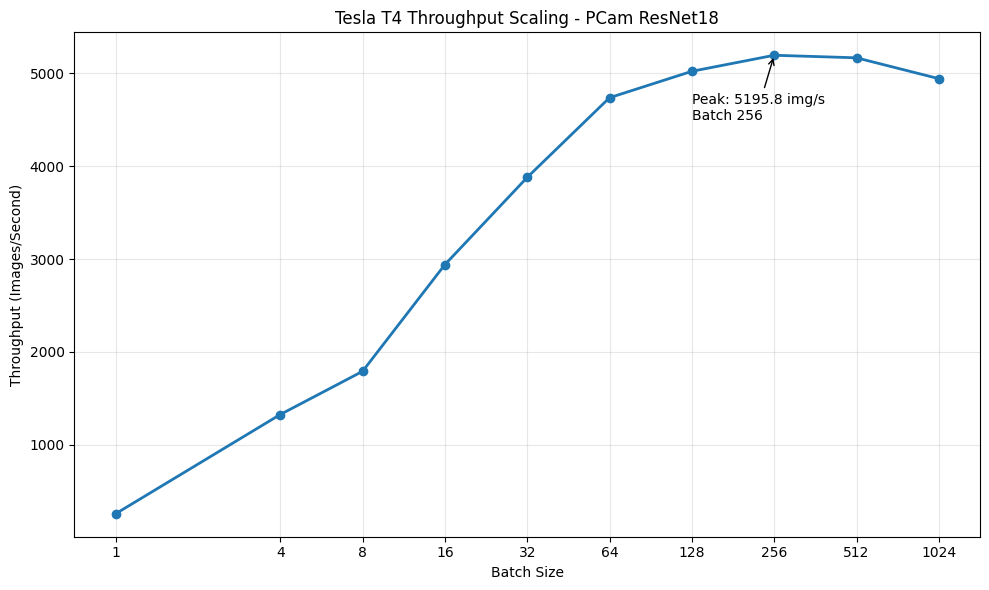

In [ ]:
import matplotlib.pyplot as plt

# Data from the Week 6 benchmark
batch = results_df["batch_size"]
throughput = results_df["throughput_img_s"]

plt.figure(figsize=(10, 6))

plt.plot(
    batch,
    throughput,
    marker="o",
    linewidth=2
)

# Use log2 spacing because batch sizes double
plt.xscale("log", base=2)

plt.xticks(
    batch,
    [str(x) for x in batch]
)

plt.xlabel("Batch Size")
plt.ylabel("Throughput (Images/Second)")
plt.title("Tesla T4 Throughput Scaling - PCam ResNet18")

plt.grid(True, alpha=0.3)

# Mark the highest measured throughput
best_index = throughput.idxmax()
best_batch = results_df.loc[best_index, "batch_size"]
best_throughput = results_df.loc[best_index, "throughput_img_s"]

plt.annotate(
    f"Peak: {best_throughput:.1f} img/s\nBatch {best_batch}",
    xy=(best_batch, best_throughput),
    xytext=(128, best_throughput - 700),
    arrowprops=dict(arrowstyle="->")
)

plt.tight_layout()
plt.show()

In [ ]:
# WEEK 6 FINAL VERIFICATION — CLEAN SETUP
# Fresh runtime: mount Drive, restore validation data, and load frozen model.

from google.colab import drive
drive.mount("/content/drive")

import os
import gzip
import shutil
import gc
import torch
import torch.nn as nn
from torchvision import models

# -----------------------------
# Paths
# -----------------------------
PCAM_DRIVE = "/content/drive/MyDrive/HC_Project/PCam"
PCAM_LOCAL = "/content/pcam_data"

checkpoint_path = (
    "/content/drive/MyDrive/HC_Project/checkpoints/"
    "pcam_resnet18_week5.pth"
)

os.makedirs(PCAM_LOCAL, exist_ok=True)

valid_files = [
    "camelyonpatch_level_2_split_valid_x.h5",
    "camelyonpatch_level_2_split_valid_y.h5"
]

# -----------------------------
# Restore ONLY validation files
# -----------------------------
for filename in valid_files:
    local_path = os.path.join(PCAM_LOCAL, filename)
    gz_path = os.path.join(PCAM_DRIVE, filename + ".gz")

    if not os.path.exists(local_path):
        print(f"Restoring {filename}...")

        with gzip.open(gz_path, "rb") as src:
            with open(local_path, "wb") as dst:
                shutil.copyfileobj(src, dst)

        print(f"Restored: {local_path}")
    else:
        print(f"Already restored: {local_path}")

# -----------------------------
# Confirm CUDA environment
# -----------------------------
assert torch.cuda.is_available(), "CUDA GPU is not available."

device = torch.device("cuda")

print("\nGPU:", torch.cuda.get_device_name(0))
print("PyTorch:", torch.__version__)

# -----------------------------
# Load frozen Week 5 checkpoint
# -----------------------------
checkpoint = torch.load(checkpoint_path, map_location="cpu")

benchmark_model = models.resnet18(weights=None)
benchmark_model.fc = nn.Linear(
    benchmark_model.fc.in_features,
    2
)

benchmark_model.load_state_dict(checkpoint["state_dict"])
benchmark_model = benchmark_model.to(device)
benchmark_model.eval()

# -----------------------------
# Clean allocator before ANY inference
# -----------------------------
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()

allocated_mib = torch.cuda.memory_allocated() / (1024 ** 2)
reserved_mib = torch.cuda.memory_reserved() / (1024 ** 2)

# Parameter + buffer footprint for comparison
model_bytes = sum(
    p.numel() * p.element_size()
    for p in benchmark_model.parameters()
)

model_bytes += sum(
    b.numel() * b.element_size()
    for b in benchmark_model.buffers()
)

model_mib = model_bytes / (1024 ** 2)

print("\n===== CLEAN WEEK 6 BASELINE =====")
print("Architecture:", checkpoint["model_architecture"])
print("Input shape:", checkpoint["input_shape"])
print("Classes:", checkpoint["class_names"])
print("Saved validation accuracy:", checkpoint["validation_accuracy"])
print()
print(f"Model parameters + buffers: {model_mib:.2f} MiB")
print(f"CUDA allocated:             {allocated_mib:.2f} MiB")
print(f"CUDA reserved:              {reserved_mib:.2f} MiB")
print("=================================")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Already restored: /content/pcam_data/camelyonpatch_level_2_split_valid_x.h5
Already restored: /content/pcam_data/camelyonpatch_level_2_split_valid_y.h5

GPU: Tesla T4
PyTorch: 2.11.0+cu128

===== CLEAN WEEK 6 BASELINE =====
Architecture: resnet18
Input shape: [3, 96, 96]
Classes: ['negative', 'metastatic']
Saved validation accuracy: 82.8125

Model parameters + buffers: 42.68 MiB
CUDA allocated:             42.69 MiB
CUDA reserved:              64.00 MiB


In [ ]:
# WEEK 6 FINAL VERIFICATION — FIXED PCAM WORKLOAD
# Build the 1,024-image benchmark tensor entirely on CPU.
# No GPU inference happens in this cell.

import h5py
import torch

valid_x_path = (
    "/content/pcam_data/"
    "camelyonpatch_level_2_split_valid_x.h5"
)

valid_y_path = (
    "/content/pcam_data/"
    "camelyonpatch_level_2_split_valid_y.h5"
)

BENCHMARK_SIZE = 1024

# -----------------------------
# Load first 1,024 official
# validation images + labels
# -----------------------------
with h5py.File(valid_x_path, "r") as f:
    images_np = f["x"][:BENCHMARK_SIZE]

with h5py.File(valid_y_path, "r") as f:
    labels_np = f["y"][:BENCHMARK_SIZE]

# HDF5: [N, H, W, C]
# PyTorch: [N, C, H, W]
benchmark_images_cpu = (
    torch.from_numpy(images_np)
    .permute(0, 3, 1, 2)
    .contiguous()
    .float()
    .div(255.0)
)

benchmark_labels_cpu = (
    torch.from_numpy(labels_np)
    .view(-1)
    .long()
)

# Same ImageNet normalization used during Week 5
mean = torch.tensor(
    [0.485, 0.456, 0.406]
).view(1, 3, 1, 1)

std = torch.tensor(
    [0.229, 0.224, 0.225]
).view(1, 3, 1, 1)

benchmark_images_cpu = (
    benchmark_images_cpu - mean
) / std

# Remove original NumPy arrays
del images_np, labels_np

# -----------------------------
# Workload information
# -----------------------------
tensor_mib = (
    benchmark_images_cpu.numel()
    * benchmark_images_cpu.element_size()
    / (1024 ** 2)
)

print("===== FIXED WEEK 6 WORKLOAD =====")
print("Images:", benchmark_images_cpu.shape)
print("Labels:", benchmark_labels_cpu.shape)
print("Device:", benchmark_images_cpu.device)
print("Data type:", benchmark_images_cpu.dtype)
print("Pinned memory:", benchmark_images_cpu.is_pinned())
print(f"CPU tensor size: {tensor_mib:.2f} MiB")

# -----------------------------
# Make sure CPU preparation
# did NOT alter CUDA baseline
# -----------------------------
torch.cuda.synchronize()

print("\n===== CUDA CHECK =====")
print(
    f"CUDA allocated: "
    f"{torch.cuda.memory_allocated() / (1024 ** 2):.2f} MiB"
)
print(
    f"CUDA reserved:  "
    f"{torch.cuda.memory_reserved() / (1024 ** 2):.2f} MiB"
)
print("======================")

===== FIXED WEEK 6 WORKLOAD =====
Images: torch.Size([1024, 3, 96, 96])
Labels: torch.Size([1024])
Device: cpu
Data type: torch.float32
Pinned memory: False
CPU tensor size: 108.00 MiB

===== CUDA CHECK =====
CUDA allocated: 42.69 MiB
CUDA reserved:  64.00 MiB


In [ ]:
# WEEK 6 FINAL VERIFICATION — T4 BENCHMARK
# Real PCam pathology images -> CPU-to-GPU -> ResNet18 -> GPU-to-CPU
# 20 warmups + 50 measured trials per batch size.

import time
import gc
import numpy as np
import pandas as pd
import torch

batch_sizes = [1, 4, 8, 16, 32, 64, 128, 256, 512, 1024]

WARMUP_RUNS = 20
MEASURED_RUNS = 50

results = []

print("===== FINAL WEEK 6 T4 BENCHMARK =====")
print("GPU:", torch.cuda.get_device_name(0))
print("Model: ResNet18")
print("Workload: PCam validation pathology images")
print("Precision: FP32")
print("CPU memory pinned:", benchmark_images_cpu.is_pinned())
print("Warmups:", WARMUP_RUNS)
print("Measured trials:", MEASURED_RUNS)
print()

for batch_size in batch_sizes:

    inputs_cpu = benchmark_images_cpu[:batch_size]

    # ----------------------------------
    # Warmup
    # ----------------------------------
    with torch.inference_mode():
        for _ in range(WARMUP_RUNS):
            warm_inputs = inputs_cpu.to(
                device,
                non_blocking=False
            )

            warm_outputs = benchmark_model(warm_inputs)

            warm_cpu = warm_outputs.to(
                "cpu",
                non_blocking=False
            )

            torch.cuda.synchronize()

            del warm_inputs
            del warm_outputs
            del warm_cpu

    # Clean temporary warmup allocations while keeping model alive
    torch.cuda.synchronize()
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

    starting_allocated = torch.cuda.memory_allocated()

    # Peak stats begin from the clean live allocation state
    torch.cuda.reset_peak_memory_stats()

    h2d_times = []
    compute_times = []
    d2h_times = []
    cuda_total_times = []
    wall_times = []
    trial_throughputs = []

    # ----------------------------------
    # Measured trials
    # ----------------------------------
    with torch.inference_mode():

        for _ in range(MEASURED_RUNS):

            h2d_start = torch.cuda.Event(enable_timing=True)
            h2d_end = torch.cuda.Event(enable_timing=True)

            compute_start = torch.cuda.Event(enable_timing=True)
            compute_end = torch.cuda.Event(enable_timing=True)

            d2h_start = torch.cuda.Event(enable_timing=True)
            d2h_end = torch.cuda.Event(enable_timing=True)

            total_start = torch.cuda.Event(enable_timing=True)
            total_end = torch.cuda.Event(enable_timing=True)

            # Make sure previous CUDA work is finished
            torch.cuda.synchronize()

            wall_start = time.perf_counter()

            # ----- Complete CUDA interval -----
            total_start.record()

            # ----- CPU -> T4 -----
            h2d_start.record()

            inputs_gpu = inputs_cpu.to(
                device,
                non_blocking=False
            )

            h2d_end.record()

            # ----- ResNet18 inference -----
            compute_start.record()

            outputs_gpu = benchmark_model(inputs_gpu)

            compute_end.record()

            # ----- T4 -> CPU -----
            d2h_start.record()

            outputs_cpu = outputs_gpu.to(
                "cpu",
                non_blocking=False
            )

            d2h_end.record()

            total_end.record()

            # Wait until all GPU work is complete
            torch.cuda.synchronize()

            wall_end = time.perf_counter()

            wall_ms = (wall_end - wall_start) * 1000.0

            h2d_times.append(
                h2d_start.elapsed_time(h2d_end)
            )

            compute_times.append(
                compute_start.elapsed_time(compute_end)
            )

            d2h_times.append(
                d2h_start.elapsed_time(d2h_end)
            )

            cuda_total_times.append(
                total_start.elapsed_time(total_end)
            )

            wall_times.append(wall_ms)

            # Throughput corresponding to this trial
            trial_throughputs.append(
                batch_size / (wall_ms / 1000.0)
            )

            # Prevent device tensors from surviving into next trial
            del inputs_gpu
            del outputs_gpu
            del outputs_cpu

    torch.cuda.synchronize()

    # ----------------------------------
    # Memory
    # ----------------------------------
    peak_allocated = torch.cuda.max_memory_allocated()
    peak_reserved = torch.cuda.max_memory_reserved()

    added_peak = peak_allocated - starting_allocated

    # ----------------------------------
    # Input size
    # ----------------------------------
    input_bytes = (
        inputs_cpu.numel()
        * inputs_cpu.element_size()
    )

    input_mib = input_bytes / (1024 ** 2)

    # ----------------------------------
    # Statistics
    # ----------------------------------
    median_h2d = float(np.median(h2d_times))
    median_compute = float(np.median(compute_times))
    median_d2h = float(np.median(d2h_times))
    median_cuda_total = float(np.median(cuda_total_times))
    median_wall = float(np.median(wall_times))
    p95_wall = float(np.percentile(wall_times, 95))

    # Mathematically this will closely correspond to
    # batch_size / median latency, but we retain the
    # per-trial values explicitly in the methodology.
    median_throughput = float(
        np.median(trial_throughputs)
    )

    # CUDA-event-derived effective H2D bandwidth
    effective_h2d_gbs = (
        input_bytes / (median_h2d / 1000.0)
    ) / 1e9

    result = {
        "batch_size": batch_size,
        "input_mib": input_mib,

        "h2d_ms": median_h2d,
        "compute_ms": median_compute,
        "d2h_ms": median_d2h,

        "cuda_total_ms": median_cuda_total,

        "wall_median_ms": median_wall,
        "wall_p95_ms": p95_wall,

        "throughput_img_s": median_throughput,

        "effective_h2d_gbs": effective_h2d_gbs,

        "starting_allocated_mib":
            starting_allocated / (1024 ** 2),

        "peak_allocated_mib":
            peak_allocated / (1024 ** 2),

        "peak_reserved_mib":
            peak_reserved / (1024 ** 2),

        "added_peak_mib":
            added_peak / (1024 ** 2)
    }

    results.append(result)

    print(
        f"Batch {batch_size:4d} | "
        f"Wall {median_wall:7.3f} ms | "
        f"P95 {p95_wall:7.3f} | "
        f"H2D {median_h2d:6.3f} | "
        f"Compute {median_compute:7.3f} | "
        f"D2H {median_d2h:6.3f} | "
        f"Throughput {median_throughput:7.1f} img/s | "
        f"Peak {peak_allocated / (1024 ** 2):7.2f} MiB"
    )

# ----------------------------------
# Final DataFrame
# ----------------------------------
results_df = pd.DataFrame(results)

print("\n===== FINAL RESULTS =====")
display(results_df.round(3))

===== FINAL WEEK 6 T4 BENCHMARK =====
GPU: Tesla T4
Model: ResNet18
Workload: PCam validation pathology images
Precision: FP32
CPU memory pinned: False
Warmups: 20
Measured trials: 50

Batch    1 | Wall   4.538 ms | P95   5.251 | H2D  0.080 | Compute   4.346 | D2H  0.041 | Throughput   220.4 img/s | Peak   54.27 MiB
Batch    4 | Wall   3.028 ms | P95   3.200 | H2D  0.176 | Compute   2.750 | D2H  0.038 | Throughput  1320.9 img/s | Peak   59.19 MiB
Batch    8 | Wall   4.422 ms | P95   4.574 | H2D  0.314 | Compute   4.009 | D2H  0.040 | Throughput  1809.0 img/s | Peak   91.61 MiB
Batch   16 | Wall   5.426 ms | P95   5.533 | H2D  0.481 | Compute   4.820 | D2H  0.043 | Throughput  2948.8 img/s | Peak   93.47 MiB
Batch   32 | Wall   8.150 ms | P95   8.343 | H2D  0.823 | Compute   7.229 | D2H  0.048 | Throughput  3926.4 img/s | Peak   99.38 MiB
Batch   64 | Wall  13.432 ms | P95  13.693 | H2D  1.517 | Compute  11.788 | D2H  0.057 | Throughput  4764.6 img/s | Peak  137.44 MiB
Batch  128 | Wall

,batch_size,input_mib,h2d_ms,compute_ms,d2h_ms,cuda_total_ms,wall_median_ms,wall_p95_ms,throughput_img_s,effective_h2d_gbs,starting_allocated_mib,peak_allocated_mib,peak_reserved_mib,added_peak_mib
0,1,0.105,0.080,4.346,0.041,4.511,4.538,5.251,220.366,1.382,51.816,54.273,68.0,2.457
1,4,0.422,0.176,2.750,0.038,3.002,3.028,3.200,1320.904,2.508,51.816,59.192,70.0,7.376
2,8,0.844,0.314,4.009,0.040,4.396,4.422,4.574,1808.959,2.817,51.816,91.613,128.0,39.797
3,16,1.688,0.481,4.820,0.043,5.397,5.426,5.533,2948.842,3.678,51.816,93.472,128.0,41.656
4,32,3.375,0.823,7.229,0.048,8.123,8.150,8.343,3926.377,4.301,51.816,99.378,168.0,47.562
5,64,6.750,1.517,11.788,0.057,13.399,13.432,13.693,4764.617,4.667,51.816,137.441,226.0,85.625
6,128,13.500,3.036,22.058,0.067,25.131,25.163,25.766,5086.794,4.663,51.816,219.816,306.0,168.000
7,256,27.000,6.157,42.632,0.083,49.106,49.137,50.004,5209.902,4.598,51.816,386.378,546.0,334.562
8,512,54.000,12.200,86.571,0.106,99.222,99.261,100.668,5158.112,4.641,51.816,718.378,1022.0,666.562
9,1024,108.000,24.705,184.708,0.130,210.520,210.560,215.032,4863.213,4.584,51.816,1384.378,1976.0,1332.562


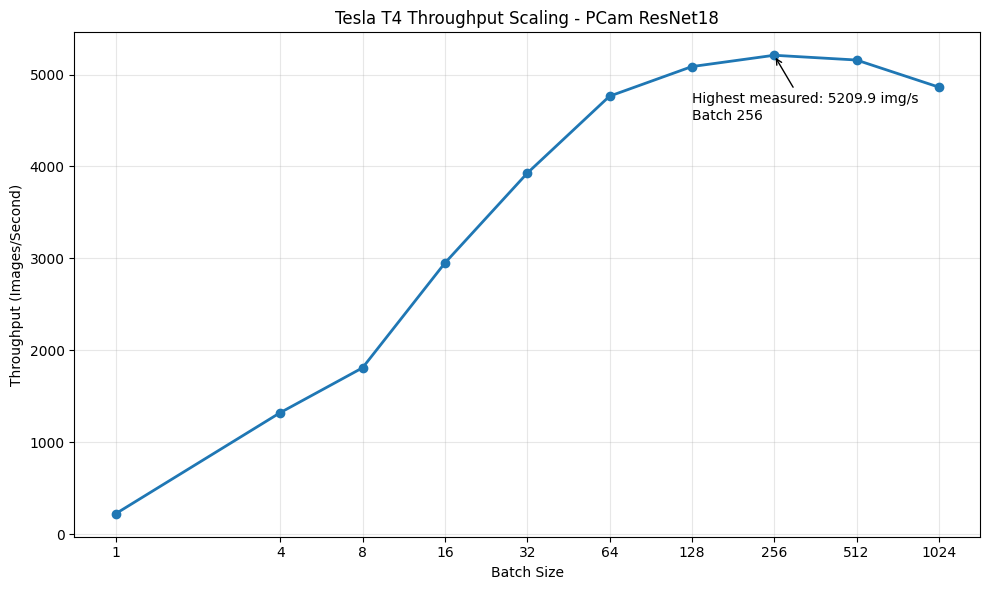

In [ ]:
# WEEK 6 FINAL GRAPH — T4 THROUGHPUT SCALING

import matplotlib.pyplot as plt

batch = results_df["batch_size"]
throughput = results_df["throughput_img_s"]

plt.figure(figsize=(10, 6))

plt.plot(
    batch,
    throughput,
    marker="o",
    linewidth=2
)

# Batch sizes double, so log2 spacing makes the progression readable
plt.xscale("log", base=2)
plt.xticks(batch, [str(x) for x in batch])

plt.xlabel("Batch Size")
plt.ylabel("Throughput (Images/Second)")
plt.title("Tesla T4 Throughput Scaling - PCam ResNet18")

plt.grid(True, alpha=0.3)

# Find highest measured throughput automatically
best_index = throughput.idxmax()
best_batch = results_df.loc[best_index, "batch_size"]
best_throughput = results_df.loc[best_index, "throughput_img_s"]

plt.annotate(
    f"Highest measured: {best_throughput:.1f} img/s\nBatch {best_batch}",
    xy=(best_batch, best_throughput),
    xytext=(128, best_throughput - 700),
    arrowprops=dict(arrowstyle="->")
)

plt.tight_layout()
plt.show()